# 유튜버 이탈 예측 및 주요 원인 분석 모델

이 노트북은 구독자 10만~100만 사이의 유튜버 데이터를 활용하여, 유튜버가 향후 이탈할 것인지(활동 중단)를 예측하고 그 주요 원인을 분석하는 모델을 구축합니다.

## 1. 환경 설정 및 데이터 로드

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from xgboost import XGBClassifier
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from scipy.stats import linregress
from functools import reduce
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'AppleGothic'  # Mac 전용 설정 (Windows/Linux인 경우 수정 필요)
plt.rcParams['axes.unicode_minus'] = False

In [24]:
# 데이터 로드
wide_df = pd.read_csv('../../data/raw/filtered_dataset_wide.csv')
long_df = pd.read_csv('../../data/raw/filtered_dataset_long.csv')
view_volatility_df = pd.read_csv('../../data/raw/view_volatility_output.csv')
upload_regularity_df = pd.read_csv('../../data/raw/upload_regularity_score.csv')
active_viewer_df = pd.read_csv('../../data/raw/active_viewer_score.csv')
sensitive_keyword_df = pd.read_csv('../../data/raw/sensitive_keyword_score.csv')

print(f"Wide dataset shape: {wide_df.shape}")
print(f"Long dataset shape: {long_df.shape}")

Wide dataset shape: (3336, 22)
Long dataset shape: (166449, 18)


## 2. 데이터 전처리 및 라벨링

마지막 업로드로부터 180일 이상 경과한 채널을 '이탈(1)'로 정의합니다.

In [25]:
CHURN_THRESHOLD = 180
wide_df['is_churned'] = (wide_df['days_since_last_upload'] >= CHURN_THRESHOLD).astype(int)


print("이탈 여부 분포 :")
print(wide_df['is_churned'].value_counts())
print(f"이탈 비율 : {wide_df['is_churned'].mean():.2%}")

이탈 여부 분포 :
is_churned
0    2641
1     695
Name: count, dtype: int64
이탈 비율 : 20.83%


## 3. 피처 엔지니어링

In [26]:
long_df['published_at'] = pd.to_datetime(long_df['published_at'])
NOW = long_df['published_at'].max()

def extract_long_features(group):
    g = group.sort_values("published_at")

    # 1. upload_slope: 월별 업로드 수 선형 기울기
    g["ym"] = g["published_at"].dt.to_period("M")
    monthly = g.groupby("ym").size().reset_index(name="cnt")
    if len(monthly) >= 3:
        slope, *_ = linregress(range(len(monthly)), monthly["cnt"])
    else:
        slope = np.nan

    # 2. recent_3m_upload_count
    t3 = NOW - pd.Timedelta(days=90)
    recent_3m = (g["published_at"] >= t3).sum()

    # 3. recent_view_ratio (최신 10개 평균 / 전체 평균)
    views = g["view_count"].dropna().tolist()
    if len(views) >= 10:
        recent_avg = np.mean(views[-10:])
        total_avg  = np.mean(views)
        view_ratio = round(recent_avg / (total_avg + 1e-9), 4)
    else:
        view_ratio = np.nan

    # 4. days_between_last2: 마지막 두 영상 사이 간격
    dates = g["published_at"].dropna().tolist()
    if len(dates) >= 2:
        days_last2 = (dates[-1] - dates[-2]).days
    else:
        days_last2 = np.nan

    return pd.Series({
        "upload_slope": slope,
        "recent_3m_upload_count": int(recent_3m),
        "recent_view_ratio": view_ratio,
        "days_between_last2": days_last2,
    })

long_features = long_df.groupby("channel_id").apply(extract_long_features).reset_index()

### 피처(Feature) 설명

#### WIDE_FEATURES — 채널 단위 집계 피처 (`wide_df`)

**채널 규모 / 누적 지표**
- `subscriber_count` : 구독자 수
- `view_count` : 채널 누적 조회수
- `total_video_count` : 채널 전체 영상 수

**업로드 패턴 (규칙성)**
- `avg_upload_interval_days` : 평균 업로드 간격(일)
- `std_upload_interval_days` : 업로드 간격의 표준편차 (들쭉날쭉함)
- `max_gap_days` : 최대 업로드 공백 기간
- `hiatus_count_30d` : 30일 이상 쉰 횟수 (휴지기 빈도)
- ~~`upload_freq_change_rate`~~ : 업로드 빈도 변화율 *(미사용)*

**영상별 성과 / 참여도**
- `avg_view_count`, `std_view_count` : 영상당 평균 조회수와 변동성
- `avg_like_count`, `avg_comment_count` : 영상당 평균 좋아요·댓글 수
- `avg_engagement_rate` : 평균 참여율 ((좋아요+댓글)/조회수 류)
- `shorts_ratio` : 전체 영상 중 쇼츠 비중
- `avg_shorts_view`, `avg_normal_view` : 쇼츠 / 일반 영상의 평균 조회수

#### LONG_FEATURES — 시계열 파생 피처 (`extract_long_features()`로 계산)

- `upload_slope` : 월별 업로드 수의 선형회귀 기울기 (음수 → 활동 감소 추세)
- ~~`recent_3m_upload_count`~~ : 최근 90일간 업로드 수 *(미사용)*
- `recent_view_ratio` : 최근 10개 영상 평균 조회수 / 전체 평균 조회수 (1 미만이면 최근 성과 하락)
- `days_between_last2` : 마지막 두 영상 사이 간격(일)

#### 병합
`df = wide_df.merge(long_features, on="channel_id", how="left")`
→ 채널 집계 데이터(`wide_df`)에 시계열 파생 피처(`long_features`)를 `channel_id` 기준으로 left join 하여 학습용 테이블 생성.

즉, **채널의 규모·성과 + 업로드 패턴 + 최근 추세** 세 축으로 이탈 여부(`is_churned`, 180일 이상 미업로드)를 예측합니다.

In [27]:
WIDE_FEATURES = [
    "subscriber_count",            # 구독자 수
    "view_count",                  # 채널 누적 조회수
    "total_video_count",           # 채널 전체 영상 수
    "avg_upload_interval_days",    # 평균 업로드 간격(일)
    "std_upload_interval_days",    # 업로드 간격 표준편차 (들쭉날쭉함)
    "max_gap_days",                # 최대 업로드 공백 기간
    "hiatus_count_30d",            # 30일 이상 쉰 횟수 (휴지기 빈도)
   # "upload_freq_change_rate",    # 업로드 빈도 변화율 (미사용)
    "avg_view_count",              # 영상당 평균 조회수
    "std_view_count",              # 영상당 조회수 변동성
    "avg_like_count",              # 영상당 평균 좋아요 수
    "avg_comment_count",           # 영상당 평균 댓글 수
    "avg_engagement_rate",         # 평균 참여율 ((좋아요+댓글)/조회수)
    "shorts_ratio",                # 전체 영상 중 쇼츠 비중
    "avg_shorts_view",             # 쇼츠 영상 평균 조회수
    "avg_normal_view"              # 일반 영상 평균 조회수
]
LONG_FEATURES = [
    "upload_slope",                # 월별 업로드 수 선형회귀 기울기 (음수=활동 감소)
    # "recent_3m_upload_count",    # 최근 90일 업로드 수 (미사용)
    "recent_view_ratio",           # 최근 10개 평균 조회수 / 전체 평균 조회수
    "days_between_last2"           # 마지막 두 영상 사이 간격(일)
]

df = wide_df.merge(long_features, on="channel_id", how="left")


In [28]:

VIEW_VOLATILITY_FEATURES = [
    #"volatility_prob"
]
UPLOAD_REGULARITY_FEATURES = [
   # "regularity_score"
]
ACTIVE_VIEWER_FEATURES = [
   ## "active_viewer_score",
    #"view_per_sub"
]
SENSITIVE_KEYWORD_FEATURES = [
    #"sensitive_score"
]

In [29]:
view_volatility_df = view_volatility_df[["channel_id", "volatility_prob"]]
upload_regularity_df = upload_regularity_df[["channel_id", "regularity_score"]]
active_viewer_df = active_viewer_df[["channel_id", "active_viewer_score", "view_per_sub"]]
sensitive_keyword_df = sensitive_keyword_df[["channel_id", "sensitive_score"]]

In [30]:
dfs = [df, view_volatility_df, upload_regularity_df, active_viewer_df, sensitive_keyword_df]

# channel_id 기준으로 전부 join

merged_df = reduce(

    lambda left, right: pd.merge(left, right, on='channel_id', how='inner'),

    dfs

)

In [31]:
merged_df.head()

,channel_id,title,published_at,subscriber_count,view_count,total_video_count,source_file,collected_video_count,days_since_last_upload,avg_upload_interval_days,...,is_churned,upload_slope,recent_3m_upload_count,recent_view_ratio,days_between_last2,volatility_prob,regularity_score,active_viewer_score,view_per_sub,sensitive_score
0,UC0_yHLyKYYvG4bzylDs3pwA,2M (투엠) ENT,2009-03-16T14:52:53Z,100000,10030245,557,channels_must_3250_3299.csv,50.0,2.0,0.96,...,0,-4.000000,50.0,0.3145,0.0,0.015,0.6257,0.6068,0.035831,0.0000
1,UCDYdwDXhbVZXkdV6kZn-0IQ,심킹 (ABYSSKIMG),2012-05-01T15:10:54Z,100000,9668787,112,channels_must_3250_3299.csv,50.0,1120.0,22.61,...,1,-0.038462,0.0,0.4962,15.0,0.991,0.4077,0.6111,0.553646,0.0733
2,UCbr6AL4ayehAkXcdBM68e8A,김PD전당포,2012-01-06T08:48:32Z,100000,2156709,135,channels_must_3250_3299.csv,50.0,448.0,36.69,...,1,-0.884848,0.0,2.3545,0.0,0.049,0.3951,0.6064,0.015161,0.0200
3,UCJQDi71H00IXCQbxAtFem3Q,DC튜브,2015-12-19T23:24:19Z,100000,30385528,2043,channels_must_3250_3299.csv,50.0,14.0,14.12,...,0,-0.062338,3.0,0.5150,7.0,0.102,0.6316,0.3551,0.050204,0.0133
4,UCR33sqrqf6rlT2AlpgyKmyA,두리 원투쓰리코,2019-03-12T15:59:11Z,109000,123170488,1630,channels_must_3250_3299.csv,50.0,1.0,0.00,...,0,NaN,50.0,0.2627,0.0,0.728,1.0000,0.6044,0.191503,0.0000


In [32]:
ALL_FEATURES = WIDE_FEATURES + LONG_FEATURES +VIEW_VOLATILITY_FEATURES+ UPLOAD_REGULARITY_FEATURES+ACTIVE_VIEWER_FEATURES+SENSITIVE_KEYWORD_FEATURES
# 결측치 처리 (중앙값)
for feat in ALL_FEATURES:
    merged_df[feat] = merged_df[feat].fillna(merged_df[feat].median())

X = merged_df[ALL_FEATURES]
y = merged_df['is_churned']

## XGBClassifier

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)


In [34]:
# 전처리, 여기서는 안함
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [36]:
cv_score = cross_val_score(model, X_train, y_train, cv =10, scoring= 'accuracy')

print(cv_score)
print('평균 : ', cv_score.mean())
print('표준편차 : ', cv_score.std())

[0.82051282 0.77777778 0.84615385 0.79828326 0.8111588  0.84978541
 0.81974249 0.85407725 0.84978541 0.84549356]
평균 :  0.8272770624701955
표준편차 :  0.024643088538963923


In [37]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


In [38]:
# 채널별 이탈 확률 매핑
# 1) test set 결과를 channel_id에 연결 (X_test의 index가 merged_df의 행 번호와 동일)
test_result = merged_df.loc[X_test.index, ['channel_id', 'title']].copy()
test_result['churn_prob'] = y_prob
test_result['is_churned'] = y_test.values
test_result = test_result.sort_values('churn_prob', ascending=False).reset_index(drop=True)

print("=== Test set: 채널별 이탈 확률 (상위 10개) ===")
print(test_result.head(10).to_string(index=False))

# 2) 전체 채널 대상 이탈 확률 (실제 서비스용)
all_prob = model.predict_proba(X)[:, 1]
channel_churn = merged_df[['channel_id', 'title']].copy()
channel_churn['churn_prob'] = all_prob
channel_churn['churn_prob_pct'] = (channel_churn['churn_prob'] * 100).round(2)
channel_churn = channel_churn.sort_values('churn_prob', ascending=False).reset_index(drop=True)

print("\n=== 전체 채널 이탈 확률 (상위 10개) ===")
print(channel_churn.head(10).to_string(index=False))
print("\n=== 전체 채널 이탈 확률 (하위 10개) ===")
print(channel_churn.tail(10).to_string(index=False))

# 필요하면 저장
# channel_churn.to_csv('../../data/processed/channel_churn_prob.csv', index=False)


=== Test set: 채널별 이탈 확률 (상위 10개) ===
              channel_id                       title  churn_prob  is_churned
UCbhdauhspaCEA7oy55STERw            Merry Play 메리플레이    0.982659           1
UCeFI3Mlzg4EmhEeSILLm69Q 슈퍼판도비 (Super Pandobi) -인기동요    0.968397           1
UCsNH6vf07dmii61iZIhw_ww                         미들뻔    0.960848           1
UCwTHUixtkE6UOZbGcAKfF6g            케이밥스타 [K-밥 STAR]    0.951412           1
UClSFlUAMQ-Yv002g8LlCqgQ                        소진소진    0.929568           1
UC2uBCRZPRAaCbUUoBt5f9Eg        맬러리 뮤직 Mallory Music    0.922816           1
UCijSFRwrNjSv9tO7EK1Wm6g              포터헤드POTTERHEAD    0.919772           1
UCGNhjyXPRc3IX308JVxeZ0g               Chiro 치로와 친구들    0.917479           1
UC6h_g9PTh4FcuCrbghYGs-g          Korean drama Trend    0.916556           1
UCsoAMpTk5pyNg3j3YZ_JueA           팅글리 [ TingGlees ]    0.910617           1

=== 전체 채널 이탈 확률 (상위 10개) ===
              channel_id                              title  churn_prob  churn_prob_pc

In [39]:
print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89       792
           1       0.59      0.39      0.47       208

    accuracy                           0.82      1000
   macro avg       0.72      0.66      0.68      1000
weighted avg       0.80      0.82      0.80      1000

ROC AUC Score: 0.8256


## 원인 분석 (SHAP)
SHAP(SHapley Additive exPlanations)를 사용하여 각 피처가 이탈 예측에 미치는 영향을 분석합니다.

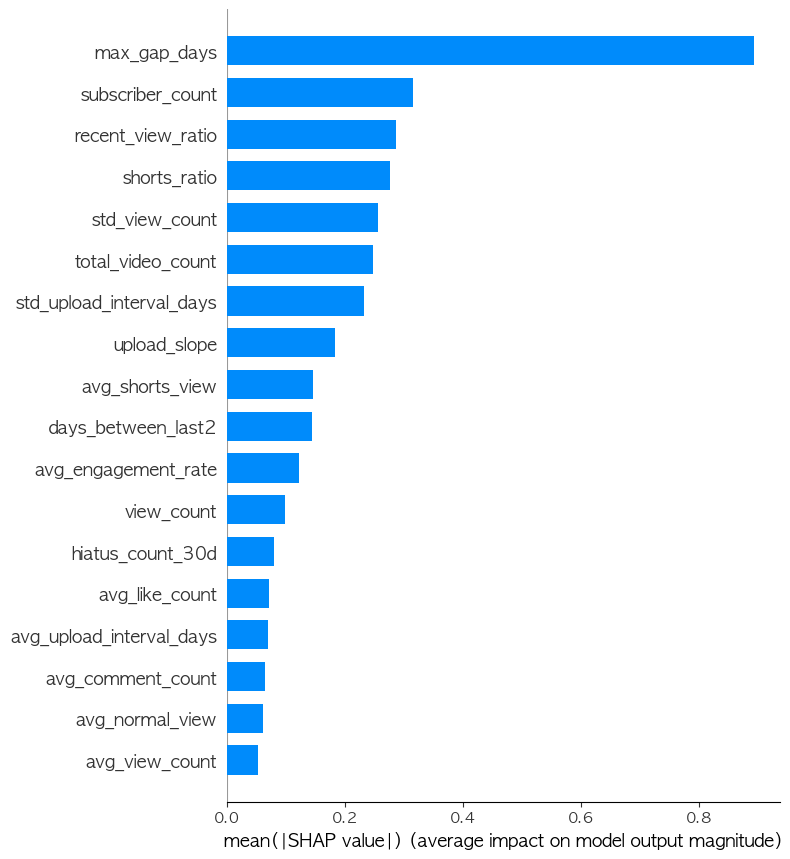

In [40]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X, plot_type="bar")

## RandomForestRegressor

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model_rdf = RandomForestRegressor(
    n_estimators=100,
    max_depth=6,
    random_state=42
    )

In [42]:
model_rdf.fit(X_train, y_train)


RandomForestRegressor(max_depth=6, random_state=42)

In [43]:
y_pred = model_rdf.predict(X_test)


In [44]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:


ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [ ]:
def predict_churn_with_reason(query):
    # query가 ID인지 타이틀인지 확인
    target = df[(df['channel_id'] == query) | (df['title'] == query)]

    if len(target) == 0:
        return f"'{query}'에 해당하는 채널을 찾을 수 없습니다."

    target_idx = target.index[0]
    target_features = X.iloc[[target_idx]]

    prob = model.predict_proba(target_features)[0][1]

    print(f"### 채널 분석 결과: {target.iloc[0]['title']} ({target.iloc[0]['channel_id']}) ###")
    print(f"이탈 확률: {prob:.2%}")

    # SHAP을 이용한 원인 분석
    instance_shap = explainer.shap_values(target_features)

    # 영향력이 큰 상위 3개 피처 추출
    shap_series = pd.Series(instance_shap[0], index=ALL_FEATURES)
    top_reasons = shap_series.abs().sort_values(ascending=False).head(3)

    print("\n[주요 원인 분석]")
    for feature, val in top_reasons.items():
        direction = "이탈 위험 증가" if shap_series[feature] > 0 else "활동 유지에 기여"
        print(f"- {feature}: {target.iloc[0][feature]} ({direction})")

    # Force plot (로컬 환경에서 시각화)
    shap.initjs()
    return shap.force_plot(explainer.expected_value, instance_shap[0], target_features.iloc[0])

# 예시 실행 (데이터에 있는 실제 채널명 입력)
# predict_churn_with_reason('2M (투엠) ENT')